In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

os.chdir(r'D:\predictive-maintenance-sme')
os.makedirs('assets', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Load data
train = pd.read_csv('data/processed/train_features.csv')
val   = pd.read_csv('data/processed/val_features.csv')
test  = pd.read_csv('data/processed/test_features.csv')

TARGET = 'Machine failure'
DROP_COLS = [TARGET, 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'rul']
FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]

X_train, y_train = train[FEATURE_COLS].fillna(0), train[TARGET]
X_val,   y_val   = val[FEATURE_COLS].fillna(0),   val[TARGET]
X_test,  y_test  = test[FEATURE_COLS].fillna(0),  test[TARGET]

# Class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Train : {X_train.shape} | Failures: {y_train.sum()}")
print(f"Val   : {X_val.shape}   | Failures: {y_val.sum()}")
print(f"Test  : {X_test.shape}  | Failures: {y_test.sum()}")
print(f"Feature count     : {len(FEATURE_COLS)}")
print(f"scale_pos_weight  : {scale_pos_weight:.2f}")


# Clean feature names — remove brackets XGBoost cannot handle
def clean_col_names(df):
    df.columns = (
        df.columns
        .str.replace('[', '', regex=False)
        .str.replace(']', '', regex=False)
        .str.replace('<', '', regex=False)
        .str.replace('>', '', regex=False)
        .str.replace(' ', '_', regex=False)
    )
    return df

train = clean_col_names(train)
val   = clean_col_names(val)
test  = clean_col_names(test)

# Redefine after cleaning
TARGET    = 'Machine_failure'
DROP_COLS = [TARGET, 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'rul']
FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]

X_train, y_train = train[FEATURE_COLS].fillna(0), train[TARGET]
X_val,   y_val   = val[FEATURE_COLS].fillna(0),   val[TARGET]
X_test,  y_test  = test[FEATURE_COLS].fillna(0),  test[TARGET]

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Feature names cleaned.")
print(f"Train : {X_train.shape} | Failures: {y_train.sum()}")
print(f"Val   : {X_val.shape}   | Failures: {y_val.sum()}")
print(f"Test  : {X_test.shape}  | Failures: {y_test.sum()}")
print(f"Feature count    : {len(FEATURE_COLS)}")
print(f"scale_pos_weight : {scale_pos_weight:.2f}")
print(f"\nSample feature names:")
for col in FEATURE_COLS[:5]:
    print(f"  {col}")

Train : (7000, 75) | Failures: 278
Val   : (1500, 75)   | Failures: 32
Test  : (1500, 75)  | Failures: 29
Feature count     : 75
scale_pos_weight  : 24.18
Feature names cleaned.
Train : (7000, 75) | Failures: 278
Val   : (1500, 75)   | Failures: 32
Test  : (1500, 75)  | Failures: 29
Feature count    : 75
scale_pos_weight : 24.18

Sample feature names:
  Air_temperature_K
  Process_temperature_K
  Rotational_speed_rpm
  Torque_Nm
  Tool_wear_min


In [5]:
print("Training XGBoost classifier...")
print("This may take 1-2 minutes.\n")

model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"\nBest iteration: {model.best_iteration}")
print("Training complete.")

Training XGBoost classifier...
This may take 1-2 minutes.

[0]	validation_0-aucpr:0.26663
[50]	validation_0-aucpr:0.69546
[100]	validation_0-aucpr:0.73852
[150]	validation_0-aucpr:0.74647
[176]	validation_0-aucpr:0.74367

Best iteration: 146
Training complete.


In [6]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== XGBoost — Default threshold (0.5) ===\n")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Failure']))

precision_val, recall_val, _ = precision_recall_curve(y_test, y_proba)
pr_auc  = auc(recall_val, precision_val)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"PR-AUC  : {pr_auc:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"F1      : {f1_score(y_test, y_pred):.4f}")
print(f"Recall  : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")

=== XGBoost — Default threshold (0.5) ===

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1471
     Failure       0.64      0.62      0.63        29

    accuracy                           0.99      1500
   macro avg       0.82      0.81      0.81      1500
weighted avg       0.99      0.99      0.99      1500

PR-AUC  : 0.6931
ROC-AUC : 0.9320
F1      : 0.6316
Recall  : 0.6207
Precision: 0.6429


Best threshold : 0.77
Best F1        : 0.6800
Recall at best : 0.5862
Precision at best: 0.8095


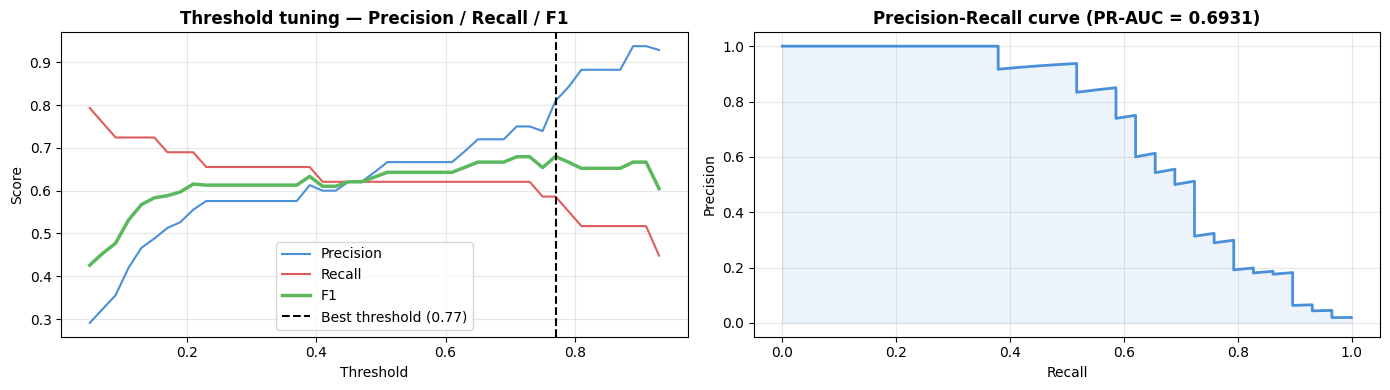

Saved: assets/xgb_threshold_tuning.png


In [7]:
thresholds = np.arange(0.05, 0.95, 0.02)
f1s, precisions, recalls = [], [], []

for t in thresholds:
    p = (y_proba >= t).astype(int)
    f1s.append(f1_score(y_test, p, zero_division=0))
    precisions.append(precision_score(y_test, p, zero_division=0))
    recalls.append(recall_score(y_test, p))

best_idx = np.argmax(f1s)
best_t   = thresholds[best_idx]

print(f"Best threshold : {best_t:.2f}")
print(f"Best F1        : {f1s[best_idx]:.4f}")
print(f"Recall at best : {recalls[best_idx]:.4f}")
print(f"Precision at best: {precisions[best_idx]:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(thresholds, precisions, label='Precision', color='#4a90d9')
axes[0].plot(thresholds, recalls,    label='Recall',    color='#e05c5c')
axes[0].plot(thresholds, f1s,        label='F1',
             color='#5cb85c', linewidth=2.5)
axes[0].axvline(best_t, color='black', linestyle='--',
                linewidth=1.5, label=f'Best threshold ({best_t:.2f})')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold tuning — Precision / Recall / F1',
                  fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PR curve
axes[1].plot(recall_val, precision_val,
             color='#4a90d9', linewidth=2)
axes[1].fill_between(recall_val, precision_val, alpha=0.1, color='#4a90d9')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall curve (PR-AUC = {pr_auc:.4f})',
                  fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('assets/xgb_threshold_tuning.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: assets/xgb_threshold_tuning.png")

=== XGBoost — Tuned threshold (0.77) ===

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      1471
     Failure       0.81      0.59      0.68        29

    accuracy                           0.99      1500
   macro avg       0.90      0.79      0.84      1500
weighted avg       0.99      0.99      0.99      1500

Confusion matrix:
  True Negative  (correct normal) : 1467
  False Positive (false alarm)     : 4
  False Negative (missed failure)  : 12  ← critical
  True Positive  (caught failure)  : 17

Caught 17 out of 29 failures (58.6%)


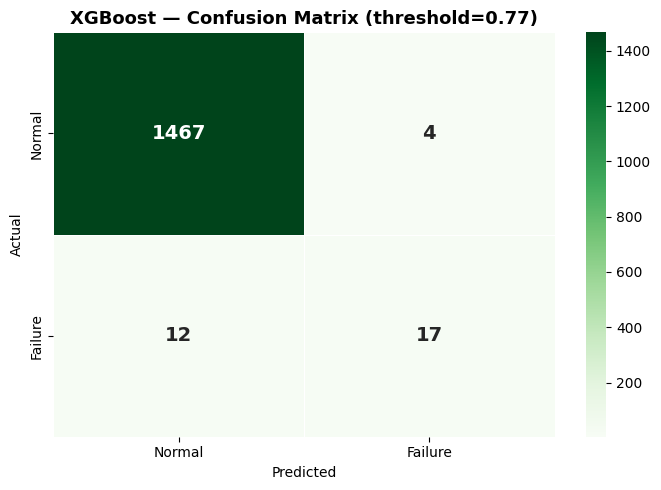

Saved: assets/xgb_cm.png


In [8]:
y_pred_tuned = (y_proba >= best_t).astype(int)

print(f"=== XGBoost — Tuned threshold ({best_t:.2f}) ===\n")
print(classification_report(y_test, y_pred_tuned,
      target_names=['Normal', 'Failure']))

cm = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion matrix:")
print(f"  True Negative  (correct normal) : {tn}")
print(f"  False Positive (false alarm)     : {fp}")
print(f"  False Negative (missed failure)  : {fn}  ← critical")
print(f"  True Positive  (caught failure)  : {tp}")
print(f"\nCaught {tp} out of {tp+fn} failures ({tp/(tp+fn)*100:.1f}%)")

# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Normal', 'Failure'],
    yticklabels=['Normal', 'Failure'],
    linewidths=0.5,
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title(f'XGBoost — Confusion Matrix (threshold={best_t:.2f})',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('assets/xgb_cm.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: assets/xgb_cm.png")

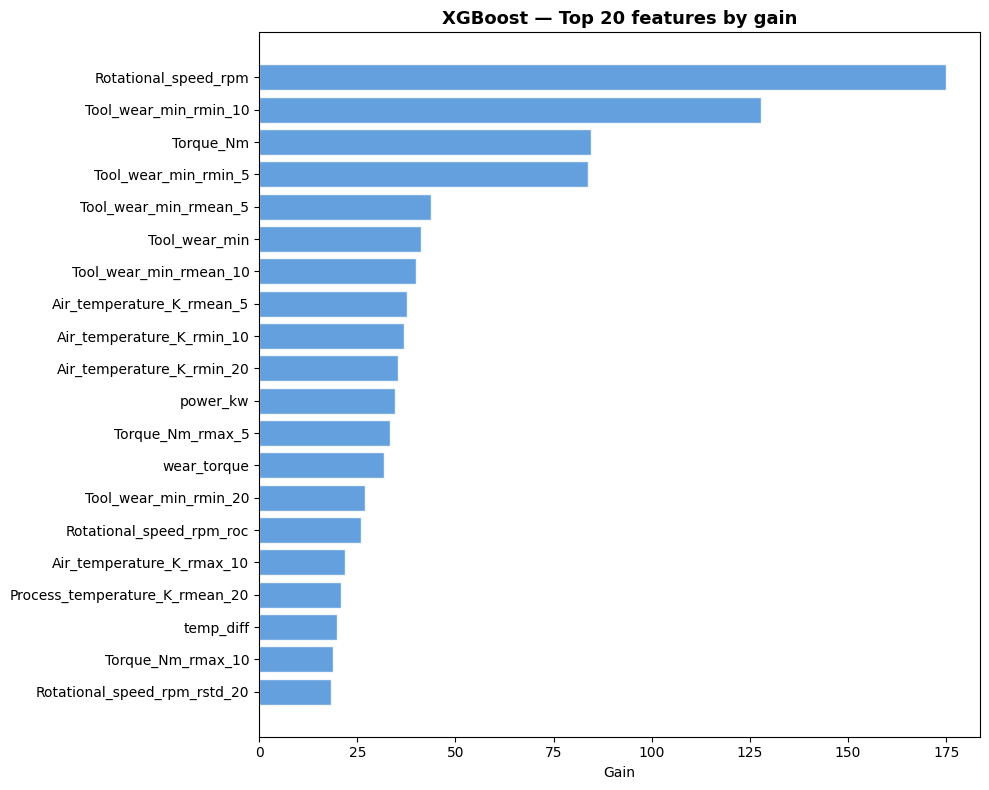

Top 10 features by gain:
  Rotational_speed_rpm                          174.87
  Tool_wear_min_rmin_10                         127.80
  Torque_Nm                                     84.51
  Tool_wear_min_rmin_5                          83.81
  Tool_wear_min_rmean_5                         43.80
  Tool_wear_min                                 41.23
  Tool_wear_min_rmean_10                        39.93
  Air_temperature_K_rmean_5                     37.65
  Air_temperature_K_rmin_10                     36.96
  Air_temperature_K_rmin_20                     35.30


In [9]:
# Get feature importance by gain
importance = model.get_booster().get_score(importance_type='gain')
imp_df = (
    pd.DataFrame(list(importance.items()),
                 columns=['feature', 'gain'])
    .sort_values('gain', ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))
bars = plt.barh(
    imp_df['feature'][::-1],
    imp_df['gain'][::-1],
    color='#4a90d9', alpha=0.85, edgecolor='white'
)
plt.xlabel('Gain')
plt.title('XGBoost — Top 20 features by gain',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/xgb_feature_importance.png',
            dpi=120, bbox_inches='tight')
plt.show()

print("Top 10 features by gain:")
for _, row in imp_df.head(10).iterrows():
    print(f"  {row['feature']:<45} {row['gain']:.2f}")

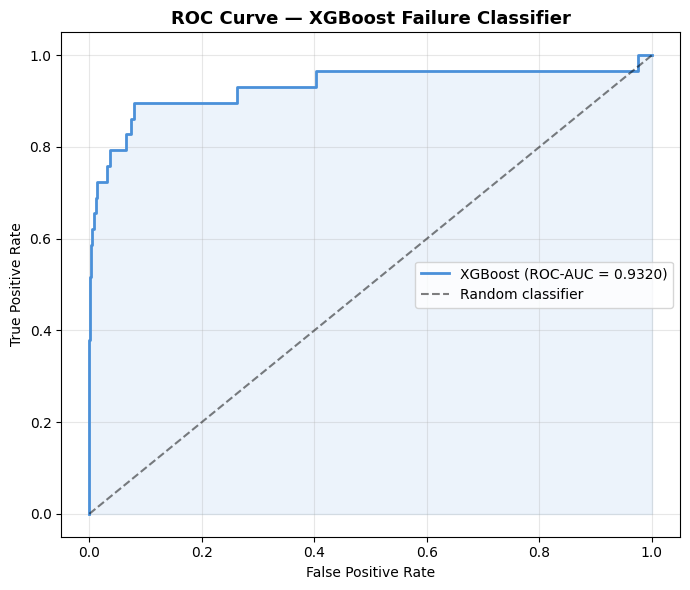

Saved: assets/xgb_roc_curve.png


In [10]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#4a90d9', linewidth=2,
         label=f'XGBoost (ROC-AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#4a90d9')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XGBoost Failure Classifier',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('assets/xgb_roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: assets/xgb_roc_curve.png")

In [11]:
# Save model
with open('models/xgboost_classifier.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save feature list
with open('models/xgb_feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

# Save tuned threshold
with open('models/xgb_threshold.pkl', 'wb') as f:
    pickle.dump(float(best_t), f)

# Save metrics
y_pred_final = (y_proba >= best_t).astype(int)
metrics = {
    'model':           'XGBoost',
    'best_threshold':  round(float(best_t), 2),
    'pr_auc':          round(float(pr_auc), 4),
    'roc_auc':         round(float(roc_auc), 4),
    'f1':              round(float(f1_score(y_test, y_pred_final)), 4),
    'recall':          round(float(recall_score(y_test, y_pred_final)), 4),
    'precision':       round(float(precision_score(
                           y_test, y_pred_final, zero_division=0)), 4),
    'best_iteration':  int(model.best_iteration),
    'feature_count':   len(FEATURE_COLS),
    'scale_pos_weight': round(float(scale_pos_weight), 2)
}

with open('models/xgb_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("=== Saved Files ===")
print("  models/xgboost_classifier.pkl")
print("  models/xgb_feature_cols.pkl")
print("  models/xgb_threshold.pkl")
print("  models/xgb_metrics.json")

print("\n=== Final XGBoost Metrics ===")
for k, v in metrics.items():
    print(f"  {k:<22}: {v}")

=== Saved Files ===
  models/xgboost_classifier.pkl
  models/xgb_feature_cols.pkl
  models/xgb_threshold.pkl
  models/xgb_metrics.json

=== Final XGBoost Metrics ===
  model                 : XGBoost
  best_threshold        : 0.77
  pr_auc                : 0.6931
  roc_auc               : 0.932
  f1                    : 0.68
  recall                : 0.5862
  precision             : 0.8095
  best_iteration        : 146
  feature_count         : 75
  scale_pos_weight      : 24.18


In [12]:
files = [
    'models/xgboost_classifier.pkl',
    'models/xgb_feature_cols.pkl',
    'models/xgb_threshold.pkl',
    'models/xgb_metrics.json',
    'assets/xgb_threshold_tuning.png',
    'assets/xgb_cm.png',
    'assets/xgb_feature_importance.png',
    'assets/xgb_roc_curve.png'
]

print("=== File verification ===")
all_good = True
for f in files:
    status = "OK     " if os.path.exists(f) else "MISSING"
    print(f"  {status} {f}")
    if "MISSING" in status:
        all_good = False

if all_good:
    print("\nAll files present. Day 6 complete.")
else:
    print("\nSome files missing. Re-run the relevant cells.")

=== File verification ===
  OK      models/xgboost_classifier.pkl
  OK      models/xgb_feature_cols.pkl
  OK      models/xgb_threshold.pkl
  OK      models/xgb_metrics.json
  OK      assets/xgb_threshold_tuning.png
  OK      assets/xgb_cm.png
  OK      assets/xgb_feature_importance.png
  OK      assets/xgb_roc_curve.png

All files present. Day 6 complete.
